In [ ]:
import pandas as pd
import numpy as np
import requests
import os
from power_forecast.params import *
from power_forecast.logic.utils.others import save_df, load_df
from power_forecast.logic.get_data.download_api import create_dataframe_base, align_start_to_column, replace_outliers_with_interpolation,add_catch24_features, add_temporal_features
from power_forecast.logic.get_data.time_features import build_feature_dataframe
#pd.set_option('display.max_columns', None)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
print(os.getcwd())

/Users/alessandrogalleani/code/alessandrog403/PowerForecast


Country            len     data from                      to

Bulgaria           65736   2016-10-01 00:00:00    -> 2024-03-31 23:00:00
Serbia             64272   2016-12-01 00:00:00       2024-03-31 23:00:00	+ nan
Croatia            56976   2017-10-01 00:00:00       2024-03-31 23:00:00
North Macedonia     8064   2023-05-01 00:00:00       2024-03-31 23:00:00. - > I WILL KILL
Ireland            68592   2015-01-01 00:00:00       2024-03-31 23:00:00. + nan. + nan

Other              81072   2015-01-01 00:00:00.      2024-03-31 23:00:00

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot_table.html

In [4]:

df = create_dataframe_base('raw_data/all_countries.csv')
print(df.shape)


(81072, 28)


In [5]:
df

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,LVA,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,17.93,34.94,NaN,43.43,24.20,17.93,18.29,48.10,23.37,23.37,...,29.59,34.94,27.36,17.18,48.10,44.17,NaN,24.20,23.25,23.37
2015-01-01 01:00:00+00:00,15.17,32.19,NaN,38.08,22.06,15.17,16.04,47.33,19.33,19.33,...,29.56,32.19,27.24,17.38,47.33,39.17,NaN,22.06,22.20,19.33
2015-01-01 02:00:00+00:00,16.38,28.05,NaN,35.47,20.27,16.38,14.60,42.27,17.66,17.66,...,29.50,28.05,27.16,17.40,42.27,26.93,NaN,20.27,19.56,17.66
2015-01-01 03:00:00+00:00,17.38,28.04,NaN,30.83,19.17,17.38,14.95,38.41,17.53,17.53,...,17.53,28.04,27.15,18.60,38.41,20.94,NaN,19.17,18.88,17.53
2015-01-01 04:00:00+00:00,16.38,34.26,NaN,28.26,17.90,16.38,14.50,35.72,18.07,18.07,...,30.52,34.26,27.30,19.30,35.72,18.52,NaN,17.90,18.39,18.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 19:00:00+00:00,66.17,47.01,65.81,74.52,68.37,70.00,70.00,3.20,50.09,50.09,...,50.09,65.20,57.09,69.99,3.20,65.81,60.05,67.09,63.43,50.09
2024-03-31 20:00:00+00:00,61.25,43.70,60.90,67.31,63.26,64.51,64.51,3.20,46.28,46.28,...,46.28,60.55,55.85,72.43,3.20,60.90,61.00,62.10,58.74,46.28
2024-03-31 21:00:00+00:00,44.99,50.29,48.07,62.86,51.29,54.90,54.90,1.63,43.98,43.98,...,43.98,54.90,53.50,75.27,1.63,48.07,59.98,49.03,46.61,43.98


In [6]:
countries_list = df.columns.to_list()
print(countries_list)

['AUT', 'BEL', 'BGR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SRB', 'SVK', 'SVN', 'SWE']


In [7]:
df_aligned = align_start_to_column(df, column='HRV', apply=True)
df_aligned.shape

(56976, 28)

In [8]:
df_aligned.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,LVA,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,...,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000
mean,95.018882,92.799807,95.466648,102.283487,91.574881,87.552664,80.338967,81.698697,81.167134,65.844656,...,87.624374,91.495600,57.448520,84.232631,82.014018,99.471928,101.797531,96.108619,101.817866,55.575055
std,102.181968,95.790414,97.121643,103.633583,96.379402,98.261122,90.991573,62.883676,86.046742,78.241071,...,96.042576,93.723884,54.039208,58.407165,62.720154,102.420787,101.320940,101.956974,102.809692,60.575689
min,-500.000000,-500.000000,-1.800000,-142.880000,-68.540000,-500.000000,-288.140000,0.000000,-60.040000,-500.000000,...,-56.550000,-500.000000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-500.000000,-60.040000
25%,36.970000,37.930000,37.240000,41.040000,37.000000,34.880000,32.990000,42.680000,36.310000,28.510000,...,37.480000,38.040000,30.010000,47.097500,43.000000,40.100000,42.330000,37.830000,42.010000,26.577500
50%,55.920000,58.265000,58.075000,61.970000,56.040000,52.420000,49.550000,60.240000,53.000000,44.620000,...,55.410000,55.960000,43.160000,63.870000,60.530000,62.630000,63.970000,58.865000,63.295000,40.380000
75%,111.022500,106.910000,114.820000,118.910000,106.052500,100.612500,92.062500,103.590000,96.072500,69.762500,...,99.600000,106.520000,69.080000,105.510000,103.800000,117.270000,117.770000,110.000000,118.160000,58.930000
max,908.900000,871.000000,936.330000,871.610000,871.000000,1047.110000,871.000000,700.000000,4000.000000,1896.000000,...,4000.000000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


In [9]:
limit_low  = -350
limit_high = 2000

In [10]:


for col in df_aligned.columns:
    n_high = (df_aligned[col] > limit_high).sum()
    n_low  = (df_aligned[col] < limit_low).sum()
    total  = n_high + n_low
    if total > 0:  # only print if there are outliers
        print(f"{col}: {n_low} below {limit_low} | {n_high} above {limit_high} | total: {total}")

AUT: 1 below -350 | 0 above 2000 | total: 1
BEL: 2 below -350 | 0 above 2000 | total: 2
DEU: 2 below -350 | 0 above 2000 | total: 2
EST: 0 below -350 | 1 above 2000 | total: 1
FIN: 10 below -350 | 0 above 2000 | total: 10
FRA: 0 below -350 | 2 above 2000 | total: 2
HRV: 1 below -350 | 0 above 2000 | total: 1
HUN: 1 below -350 | 0 above 2000 | total: 1
LTU: 0 below -350 | 2 above 2000 | total: 2
LUX: 2 below -350 | 0 above 2000 | total: 2
LVA: 0 below -350 | 2 above 2000 | total: 2
NLD: 5 below -350 | 0 above 2000 | total: 5
SVN: 1 below -350 | 0 above 2000 | total: 1


In [11]:


total_low  = (df_aligned < limit_low).sum().sum()
total_high = (df_aligned > limit_high).sum().sum()

print(f"Below {limit_low}:  {total_low} values")
print(f"Above {limit_high}: {total_high} values")
print(f"Total to replace:   {total_low + total_high} / {df.size} ({(total_low + total_high) / df.size * 100:.4f}%)")

Below -350:  25 values
Above 2000: 7 values
Total to replace:   32 / 2270016 (0.0014%)


In [12]:


for col in df_aligned.columns:
    mask = (df_aligned[col] < limit_low) | (df_aligned[col] > limit_high)
    if mask.any():
        outlier_dates = df_aligned[mask][col]
        print(f"\n{col} — {len(outlier_dates)} outliers:")
        print(outlier_dates.to_string())  # prints timestamp + value



AUT — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

BEL — 2 outliers:
datetime_utc
2019-06-08 00:00:00+00:00   -500.0
2019-06-08 03:00:00+00:00   -500.0

DEU — 2 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0
2023-07-02 13:00:00+00:00   -399.0

EST — 1 outliers:
datetime_utc
2022-08-17 15:00:00+00:00    4000.0

FIN — 10 outliers:
datetime_utc
2023-11-24 13:00:00+00:00   -500.0
2023-11-24 14:00:00+00:00   -500.0
2023-11-24 15:00:00+00:00   -500.0
2023-11-24 16:00:00+00:00   -500.0
2023-11-24 17:00:00+00:00   -500.0
2023-11-24 18:00:00+00:00   -500.0
2023-11-24 19:00:00+00:00   -500.0
2023-11-24 20:00:00+00:00   -500.0
2023-11-24 21:00:00+00:00   -500.0
2023-11-24 22:00:00+00:00   -500.0

FRA — 2 outliers:
datetime_utc
2022-04-04 05:00:00+00:00    2712.99
2022-04-04 06:00:00+00:00    2987.78

HRV — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

HUN — 1 outliers:
datetime_utc
2023-07-02 12:00:00+00:00   -500.0

LTU — 2 outliers:
datetime_utc
2022-0

In [13]:


df_clean = replace_outliers_with_interpolation(df_aligned, limit_low=-350, limit_high=3200)

In [14]:
df_clean.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,LVA,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,56976.00000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,...,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000
mean,95.02571,92.809022,95.466648,102.283487,91.574881,87.561578,80.338967,81.698697,81.110094,65.933996,...,87.567334,91.518411,57.448520,84.232631,82.014018,99.471928,101.797531,96.108619,101.825411,55.575055
std,102.15520,95.746262,97.121643,103.633583,96.379402,98.223559,90.991573,62.883676,84.512415,77.884817,...,94.674281,93.618197,54.039208,58.407165,62.720154,102.420787,101.320940,101.956974,102.781296,60.575689
min,-140.00000,-350.000000,-1.800000,-142.880000,-68.540000,-266.920000,-288.140000,0.000000,-60.040000,-60.040000,...,-56.550000,-252.920000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-83.810000,-60.040000
25%,36.97000,37.930000,37.240000,41.040000,37.000000,34.880000,32.990000,42.680000,36.310000,28.510000,...,37.480000,38.040000,30.010000,47.097500,43.000000,40.100000,42.330000,37.830000,42.010000,26.577500
50%,55.92000,58.265000,58.075000,61.970000,56.040000,52.420000,49.550000,60.240000,53.000000,44.620000,...,55.410000,55.960000,43.160000,63.870000,60.530000,62.630000,63.970000,58.865000,63.295000,40.380000
75%,111.02250,106.910000,114.820000,118.910000,106.052500,100.612500,92.062500,103.590000,96.072500,69.762500,...,99.600000,106.520000,69.080000,105.510000,103.800000,117.270000,117.770000,110.000000,118.160000,58.930000
max,908.90000,871.000000,936.330000,871.610000,871.000000,1047.110000,871.000000,700.000000,1896.000000,1896.000000,...,2100.080000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


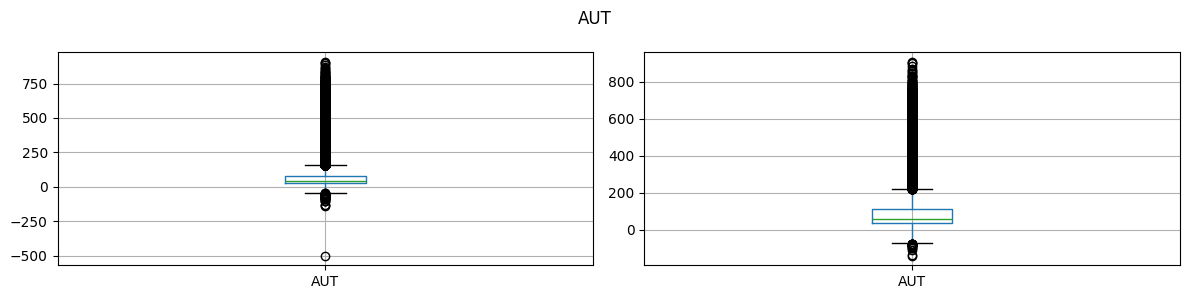

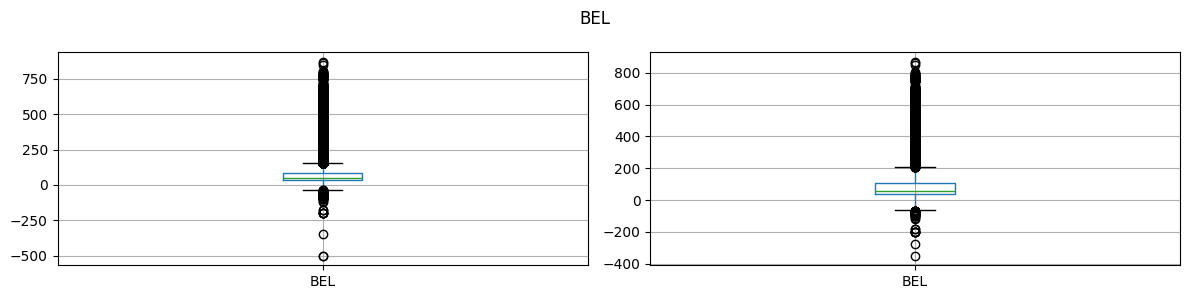

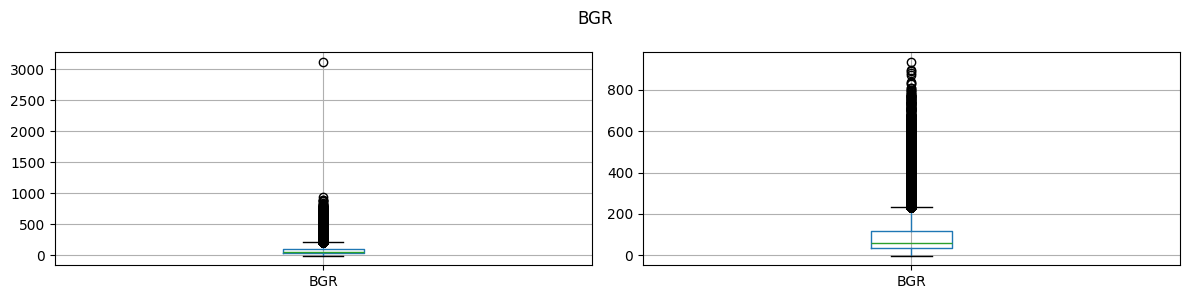

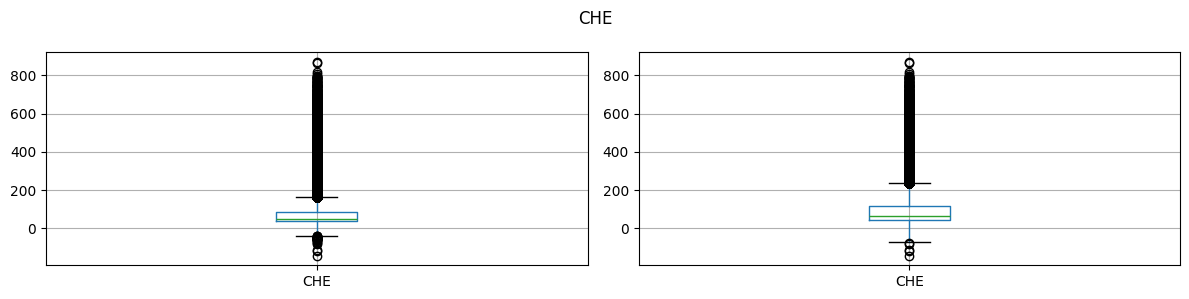

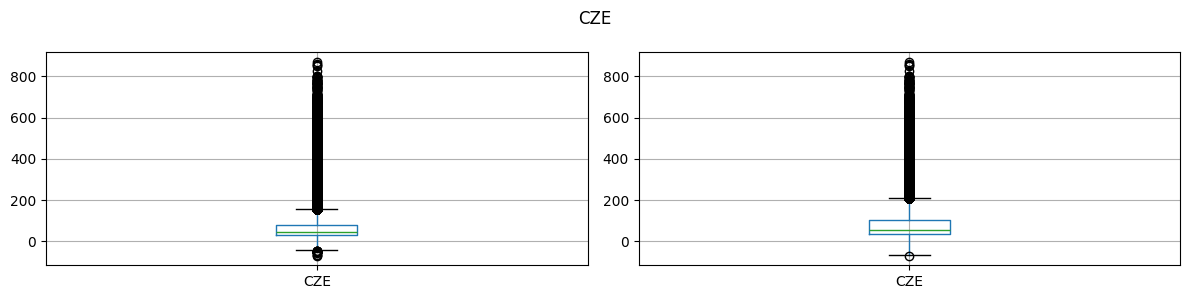

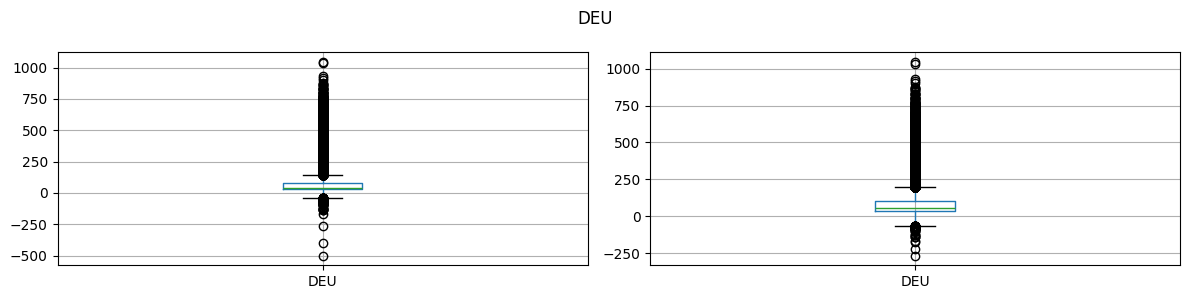

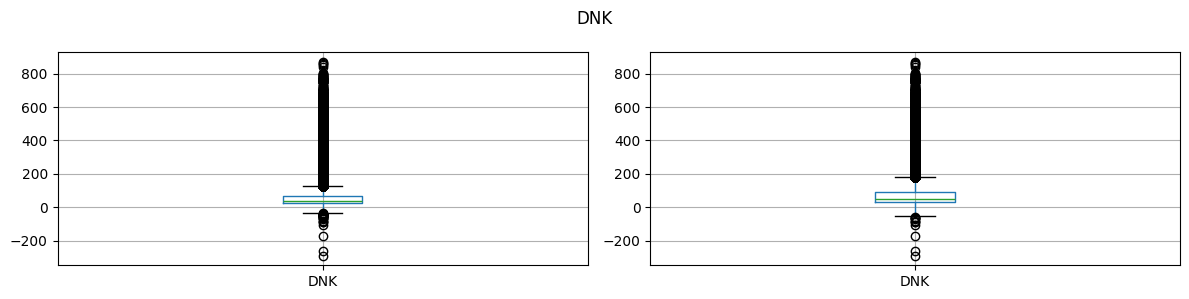

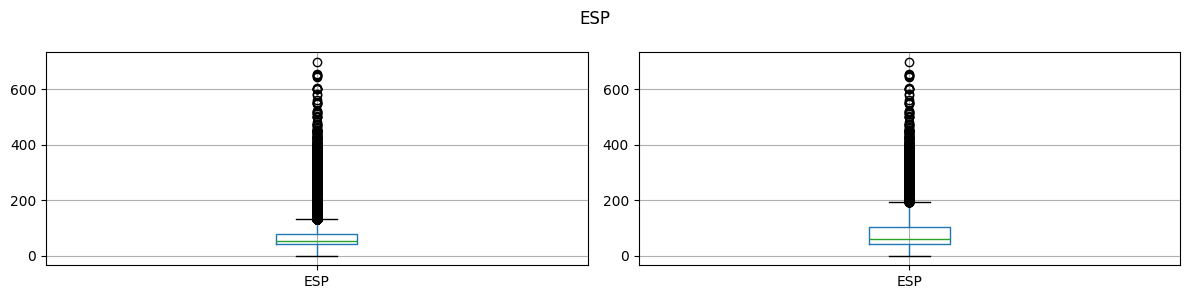

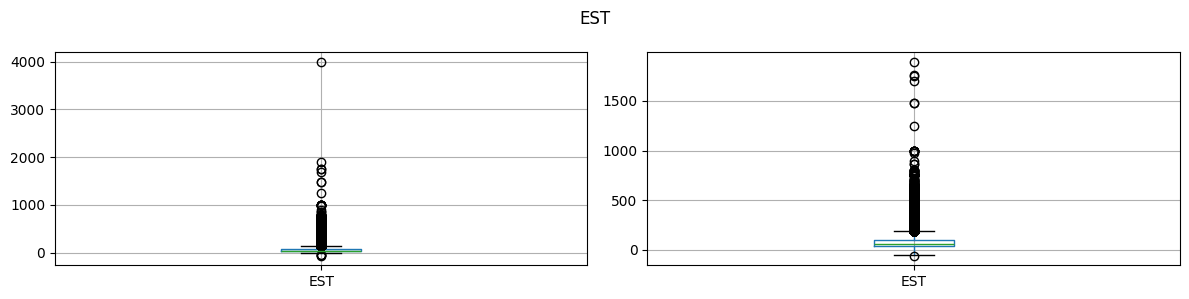

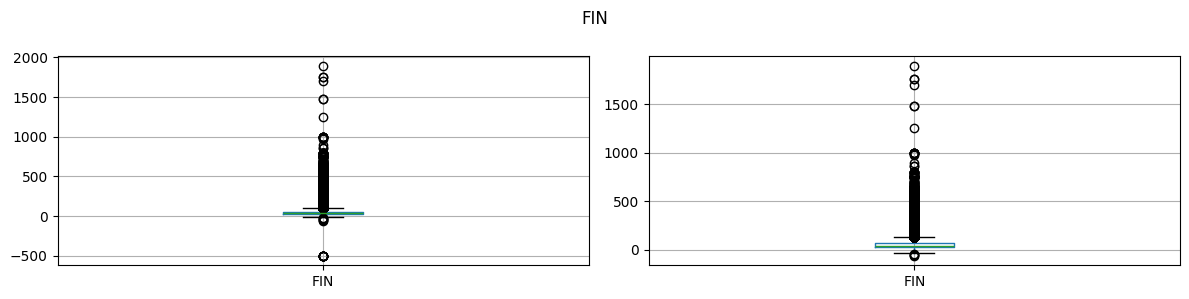

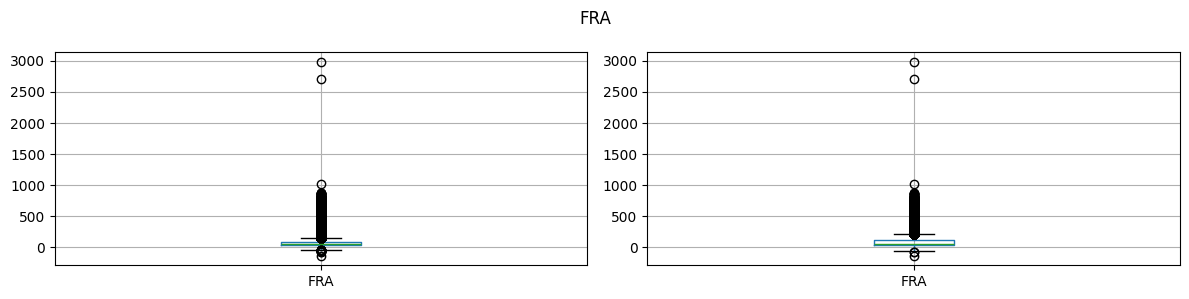

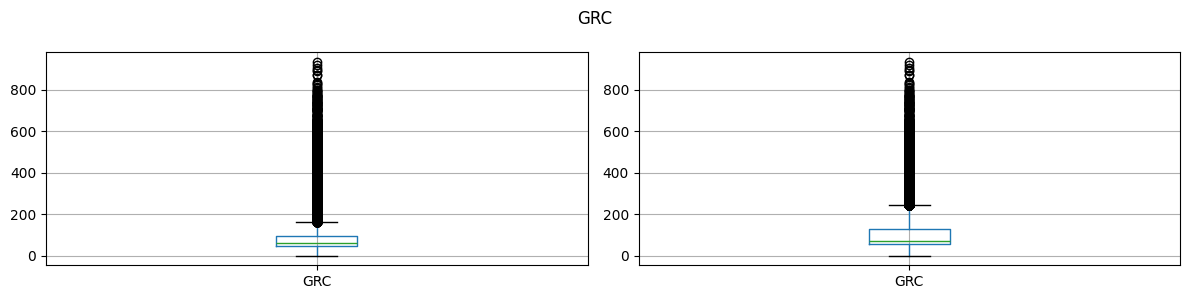

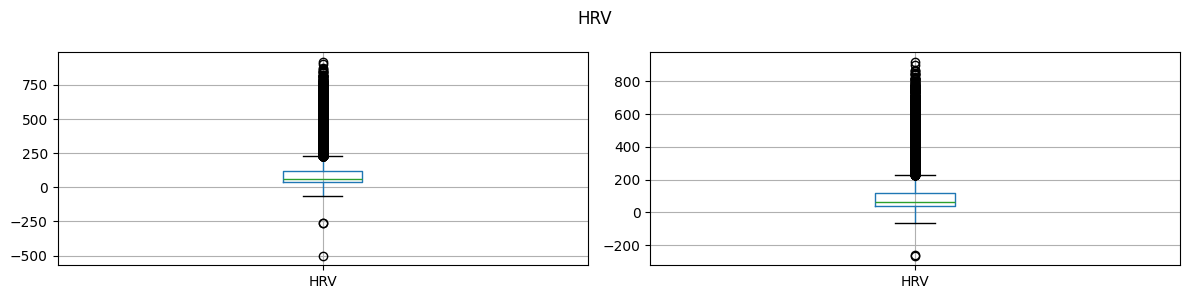

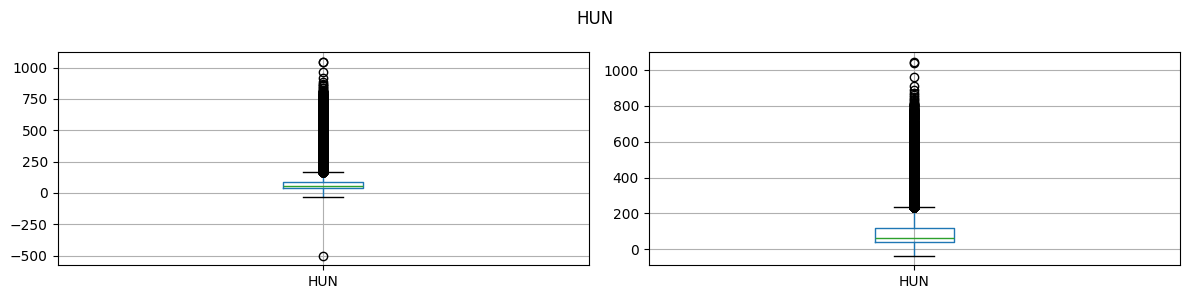

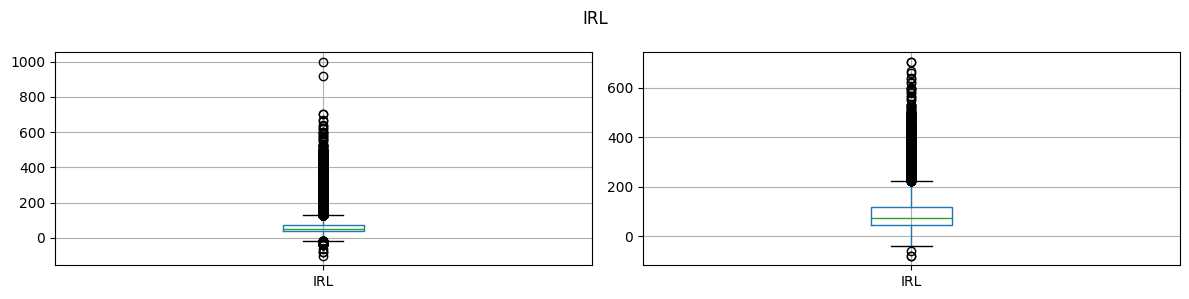

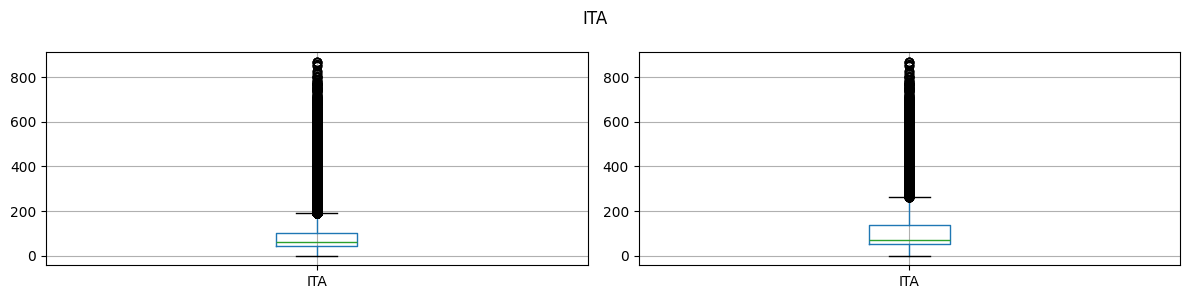

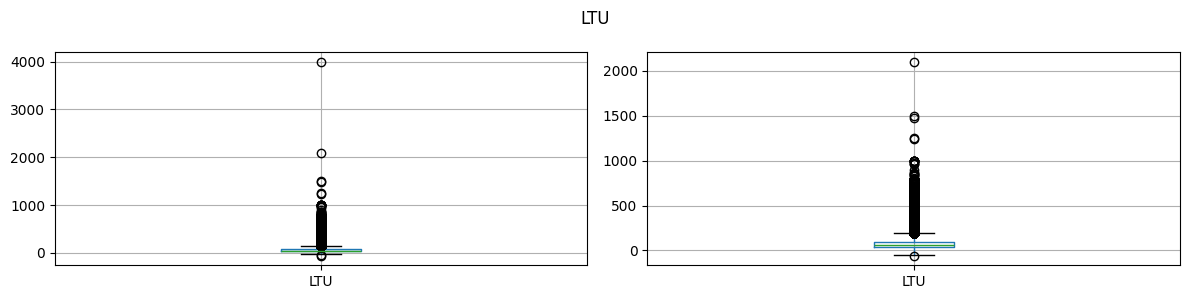

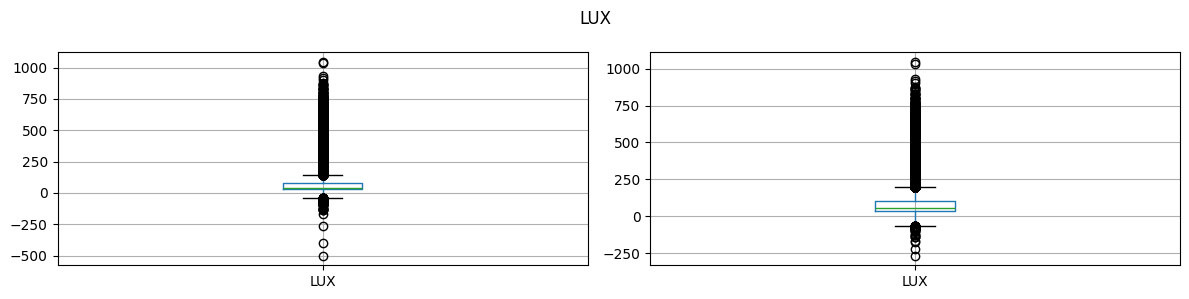

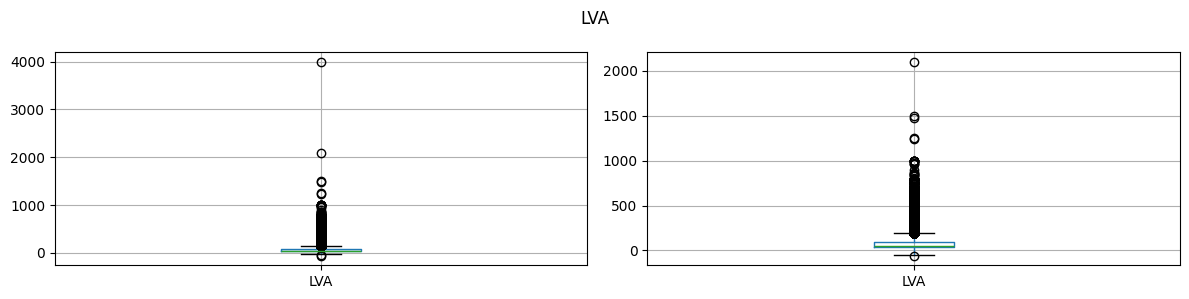

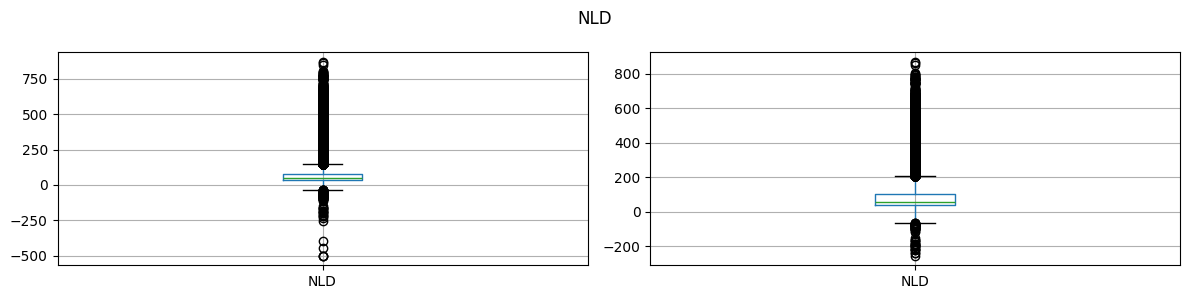

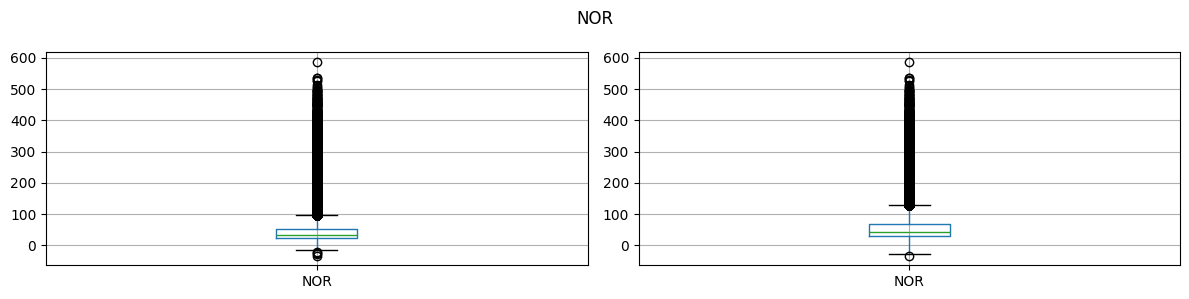

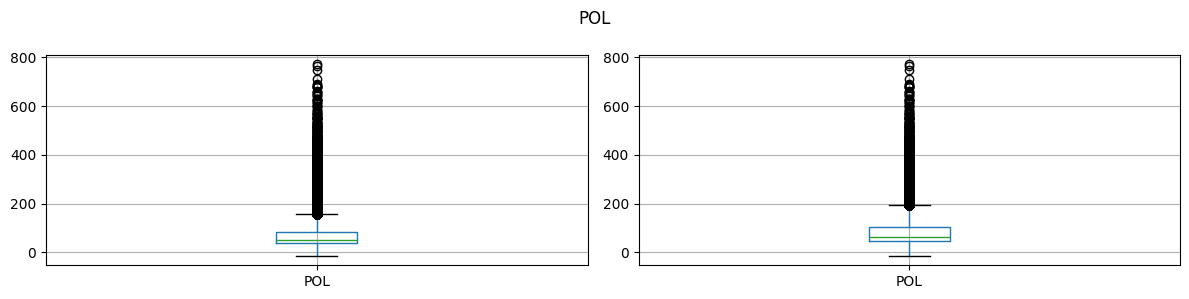

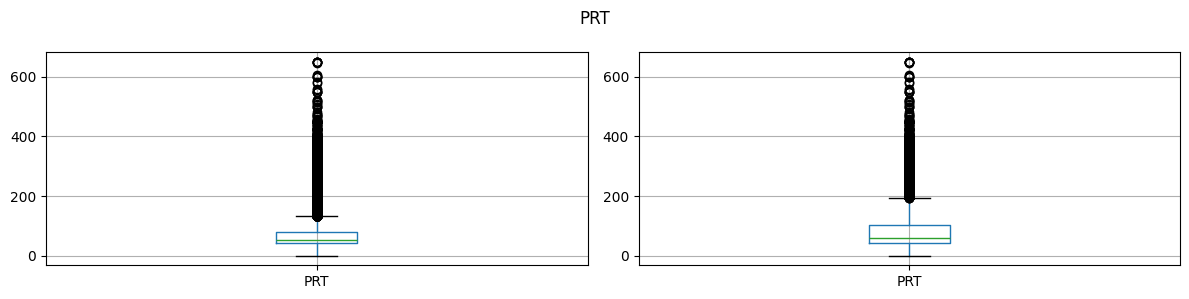

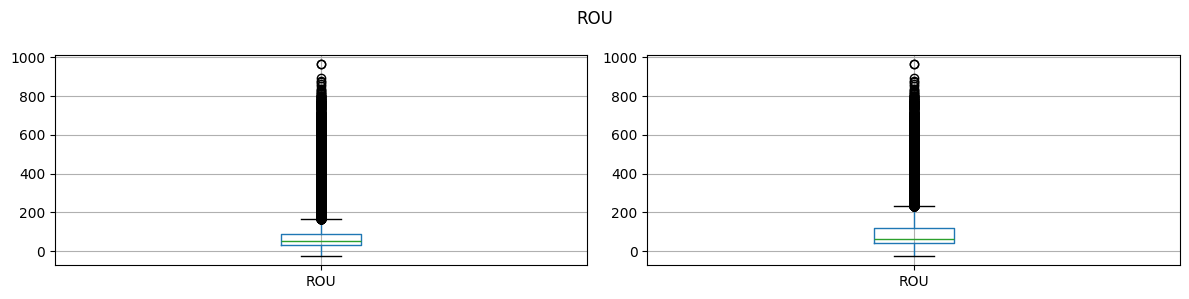

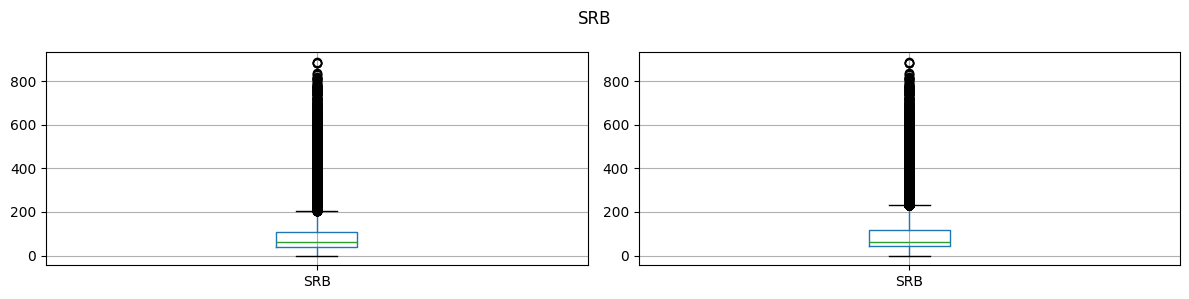

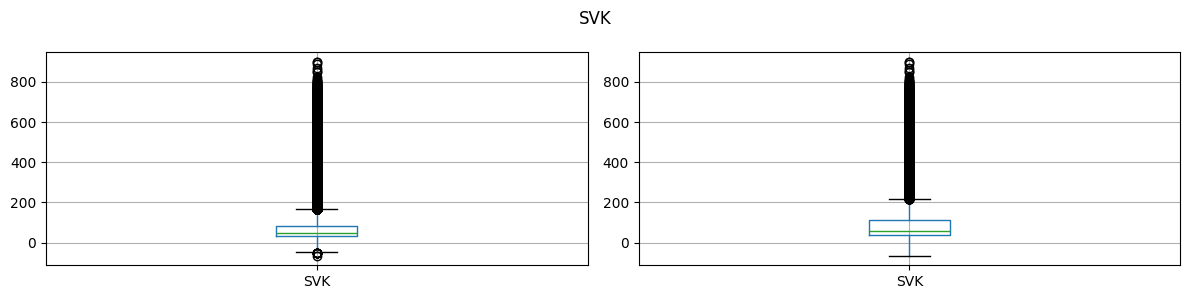

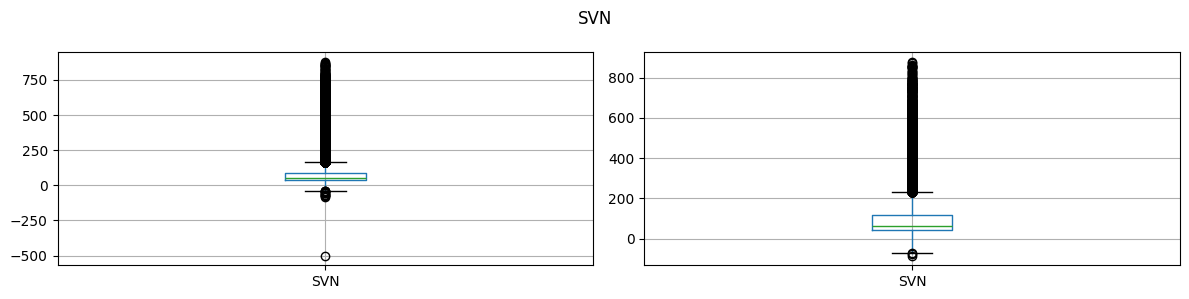

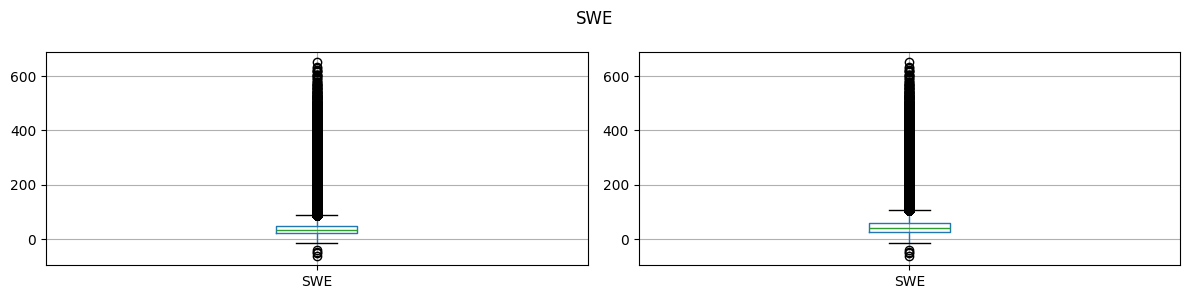

In [15]:
from matplotlib import pyplot as plt


for feature in df.select_dtypes(include='number').columns:  # ← add .columns
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))  # ← plt.subplots not df.subplots
    fig.suptitle(feature)
    
    df[[feature]].boxplot(ax=ax[0])
    df_clean[[feature]].boxplot(ax=ax[1])
    
    plt.tight_layout()
    plt.show()

In [16]:
df_clean.describe()

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,LVA,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
count,56976.00000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,...,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000,56976.000000
mean,95.02571,92.809022,95.466648,102.283487,91.574881,87.561578,80.338967,81.698697,81.110094,65.933996,...,87.567334,91.518411,57.448520,84.232631,82.014018,99.471928,101.797531,96.108619,101.825411,55.575055
std,102.15520,95.746262,97.121643,103.633583,96.379402,98.223559,90.991573,62.883676,84.512415,77.884817,...,94.674281,93.618197,54.039208,58.407165,62.720154,102.420787,101.320940,101.956974,102.781296,60.575689
min,-140.00000,-350.000000,-1.800000,-142.880000,-68.540000,-266.920000,-288.140000,0.000000,-60.040000,-60.040000,...,-56.550000,-252.920000,-32.710000,-13.810000,0.000000,-23.180000,0.000000,-65.000000,-83.810000,-60.040000
25%,36.97000,37.930000,37.240000,41.040000,37.000000,34.880000,32.990000,42.680000,36.310000,28.510000,...,37.480000,38.040000,30.010000,47.097500,43.000000,40.100000,42.330000,37.830000,42.010000,26.577500
50%,55.92000,58.265000,58.075000,61.970000,56.040000,52.420000,49.550000,60.240000,53.000000,44.620000,...,55.410000,55.960000,43.160000,63.870000,60.530000,62.630000,63.970000,58.865000,63.295000,40.380000
75%,111.02250,106.910000,114.820000,118.910000,106.052500,100.612500,92.062500,103.590000,96.072500,69.762500,...,99.600000,106.520000,69.080000,105.510000,103.800000,117.270000,117.770000,110.000000,118.160000,58.930000
max,908.90000,871.000000,936.330000,871.610000,871.000000,1047.110000,871.000000,700.000000,1896.000000,1896.000000,...,2100.080000,871.000000,587.630000,771.000000,651.000000,964.210000,889.520000,900.230000,879.290000,652.670000


In [17]:
# df_2023 = df[df.index.year == 2023].copy()
# df_2023 = df_2023[['FRA', 'BEL']]
# df_2023

In [18]:
# # ── STEP 2: Short feature names ───────────────────────────────────────────────
# features_short = [
#     'mode_5',               # Most common price range (coarse) — where prices "sit" most often
#     'mode_10',              # Most common price range (fine) — more precise price clustering
#     'acf_timescale',        # How fast price autocorrelation decays — short=noisy, long=persistent
#     'acf_first_min',        # Lag of first autocorrelation minimum — typical price cycle length
#     'ami2',                 # Non-linear dependency between lagged values — hidden price patterns
#     'trev',                 # Time reversibility — is the price series asymmetric (spikes vs drops)?
#     'high_fluctuation',     # Proportion of large hour-to-hour changes — overall volatility
#     'stretch_high',         # Longest consecutive run above mean — sustained high price periods
#     'transition_matrix',    # Self-similarity across time — how repetitive is the price behavior?
#     'periodicity',          # Dominant cycle length — detects 24h or 168h seasonality
#     'embedding_dist',       # Structure in 2D phase space — complexity of price dynamics
#     'ami_timescale',        # Lag where mutual information first drops — non-linear memory length
#     'whiten_timescale',     # Timescale after removing linear structure — residual complexity
#     'outlier_timing_pos',   # Timing of positive price spikes — when do peaks tend to occur?
#     'outlier_timing_neg',   # Timing of negative price spikes — when do price crashes occur?
#     'low_freq_power',       # Energy in low frequencies — strength of slow trend component
#     'stretch_decreasing',   # Longest consecutive price decrease — bearish pressure duration
#     'entropy_pairs',        # Entropy of consecutive value pairs — randomness/predictability
#     'rs_range',             # Rescaled range scaling — Hurst-like long memory indicator
#     'dfa',                  # Detrended fluctuation analysis — long-range dependence strength
#     'centroid_freq',        # Center of mass of power spectrum — dominant frequency of prices
#     'forecast_error',       # Error of naive local mean forecast — how predictable is the series?
#      'mean',                # Average price level — overall costliness of electricity
#      'std'                  # Price variability — how much do prices fluctuate around the mean?
# ]

# # Your setup:
# window_size = 168  # catch22 sees 1 full week → captures weekly patterns ✅
# step        = 24   # one feature row per day  → ~365 rows for 2024 ✅

# # If you changed step=1:
# # → same feature quality, but ~8,700 rows (one per hour) and 29x slower

# # If you changed window_size=24:
# # → catch22 only sees 1 day → misses weekly seasonality ❌

In [19]:
window_size = 168   # 1 week lookback, place 7 if daily values
step        = 24    # 1 day step → one row per day, place 1 if daily values
countries   = df_clean.columns.tolist()
#countries   = df_2023.columns.tolist()

In [20]:
countries

['AUT',
 'BEL',
 'BGR',
 'CHE',
 'CZE',
 'DEU',
 'DNK',
 'ESP',
 'EST',
 'FIN',
 'FRA',
 'GRC',
 'HRV',
 'HUN',
 'IRL',
 'ITA',
 'LTU',
 'LUX',
 'LVA',
 'NLD',
 'NOR',
 'POL',
 'PRT',
 'ROU',
 'SRB',
 'SVK',
 'SVN',
 'SWE']

In [21]:
df_enriched = add_catch24_features(df, window=7, step=1)

In [22]:
df_enriched.columns

Index(['AUT', 'BEL', 'BGR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN',
       ...
       'SWE_DN_OutlierInclude_n_001_mdrmd',
       'SWE_SP_Summaries_welch_rect_area_5_1',
       'SWE_SB_BinaryStats_diff_longstretch0', 'SWE_SB_MotifThree_quantile_hh',
       'SWE_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
       'SWE_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1',
       'SWE_SP_Summaries_welch_rect_centroid',
       'SWE_FC_LocalSimple_mean3_stderr', 'SWE_DN_Mean', 'SWE_DN_Spread_Std'],
      dtype='str', length=700)

In [24]:
df = add_temporal_features(df_enriched)

In [25]:
df

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,is_peak_hour,is_offpeak_hour,is_summer,is_winter
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,17.93,34.94,NaN,43.43,24.20,17.93,18.29,48.10,23.37,23.37,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 01:00:00+00:00,15.17,32.19,NaN,38.08,22.06,15.17,16.04,47.33,19.33,19.33,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 02:00:00+00:00,16.38,28.05,NaN,35.47,20.27,16.38,14.60,42.27,17.66,17.66,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 03:00:00+00:00,17.38,28.04,NaN,30.83,19.17,17.38,14.95,38.41,17.53,17.53,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 04:00:00+00:00,16.38,34.26,NaN,28.26,17.90,16.38,14.50,35.72,18.07,18.07,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 19:00:00+00:00,66.17,47.01,65.81,74.52,68.37,70.00,70.00,3.20,50.09,50.09,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,1,0,0,0
2024-03-31 20:00:00+00:00,61.25,43.70,60.90,67.31,63.26,64.51,64.51,3.20,46.28,46.28,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,0,0,0,0
2024-03-31 21:00:00+00:00,44.99,50.29,48.07,62.86,51.29,54.90,54.90,1.63,43.98,43.98,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,0,0,0,0


In [26]:
countries_list

['AUT',
 'BEL',
 'BGR',
 'CHE',
 'CZE',
 'DEU',
 'DNK',
 'ESP',
 'EST',
 'FIN',
 'FRA',
 'GRC',
 'HRV',
 'HUN',
 'IRL',
 'ITA',
 'LTU',
 'LUX',
 'LVA',
 'NLD',
 'NOR',
 'POL',
 'PRT',
 'ROU',
 'SRB',
 'SVK',
 'SVN',
 'SWE']

In [ ]:
# df_1 = df.copy()
# save_df(df_1, 'df_level_1')


Saved → raw_data/pickle_files/df_level_1.pkl | 444.13 MB


In [ ]:

# df_2 = load_df('df_level_1')

Loaded ← raw_data/pickle_files/df_level_1.pkl | 81072 rows x 720 columns


In [45]:
df

,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,FIN,...,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,is_peak_hour,is_offpeak_hour,is_summer,is_winter
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,17.93,34.94,NaN,43.43,24.20,17.93,18.29,48.10,23.37,23.37,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 01:00:00+00:00,15.17,32.19,NaN,38.08,22.06,15.17,16.04,47.33,19.33,19.33,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 02:00:00+00:00,16.38,28.05,NaN,35.47,20.27,16.38,14.60,42.27,17.66,17.66,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 03:00:00+00:00,17.38,28.04,NaN,30.83,19.17,17.38,14.95,38.41,17.53,17.53,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
2015-01-01 04:00:00+00:00,16.38,34.26,NaN,28.26,17.90,16.38,14.50,35.72,18.07,18.07,...,0.433884,-0.900969,0.000000,1.0,0.017213,0.999852,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 19:00:00+00:00,66.17,47.01,65.81,74.52,68.37,70.00,70.00,3.20,50.09,50.09,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,1,0,0,0
2024-03-31 20:00:00+00:00,61.25,43.70,60.90,67.31,63.26,64.51,64.51,3.20,46.28,46.28,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,0,0,0,0
2024-03-31 21:00:00+00:00,44.99,50.29,48.07,62.86,51.29,54.90,54.90,1.63,43.98,43.98,...,-0.781831,0.623490,0.866025,0.5,0.999991,0.004304,0,0,0,0
